# OneFormer: One Transformer to Rule Universal Image Segmentation

> MaskFormer learns to produce segments. OneFormer adds a "task instruction" so the same model can deliberately behave as semantic, instance or panoptic segmenter.


Imagine we have this image:

```
       🧑        🚗
   🌳       🛣️       🌳

```

we can ask three different questions.

Question A - Semnatic

> " What category does every pixel belong to ?


```
person
car
tree
road
```

We dont care about individual object identities.

QUestion B - Instance

> "Where is every individual object ?"


```
person #1
car #1
tree #1
tree #2

```

Question C - Panoptic

> "Tell me the category of every pixel and distinguish individual objects

```
person #1
car #1
tree #1
tree #2
road

```

we had something like

```
             IMAGE
               │
       ┌───────┼────────┐
       ▼       ▼        ▼
   Semantic Instance  Panoptic
    model     model     model

```

Three tasks → potentially three models/traininh pipelines

OneFormer asks:

> "why cant we have one model that knows how to do all three ?

The worker is same model and instruction is task input.

```
     SAME IMAGE
                     │
          ┌──────────┼──────────┐
          │          │          │
      "semantic" "instance" "panoptic"
          │          │          │
          ▼          ▼          ▼
       SAME MODEL / OneFormer
          │          │          │
          ▼          ▼          ▼
      semantic   instance    panoptic
       result      result       result

```

This is OneFormer

Task conditioning:

OneFormer adds another important piece:

> What task am i supposed to perform ?

That is called task conditioning.

Conceptually:

```
Image
 +
Task instruction
 ↓
OneFormer
 ↓
task-specific segmentation

```


Task Token: Model converts the task into a learned representation.

For example:

```
"semantic"
     ↓
task token
     ↓
[0.12, -0.73, 0.44, ...]

```

Similarly:

```
"instance"
     ↓
task token
```

and:

```
"panoptic"
     ↓
task token

```
The model then uses this information to influence its processing.


```
Task token
    ↓
"What kind of segmentation do you want?"
    ↓
Transformer
    ↓
appropriate segmentation behavior

```


MaskFormer vs OneFormer

MaskFormer:


```
IMAGE
  ↓
Backbone
  ↓
Pixel features
  ↓
Transformer
  ↓
Queries
  ↓
Class + Mask

```

OneFormer:

```
IMAGE
  +
TASK
  ↓
Backbone
  ↓
Pixel features
  ↓
Task-conditioned Transformer
  ↓
Task-guided queries
  ↓
Class + Mask

```


Key addition is:

```
          TASK
              ↓
IMAGE → OneFormer → SEGMENTS
```

It is difficult because semantic segmentation and instance segmentation dont ask exactly same thing.

Semantic:

> "all these pixels are cat"

Instance:

> The pixels are cat #1 and these other pixels are cat #2

Panoptic

> Give me both category information and instance identity

so if we train one model on all these tasks, the model could become confused.


OneFormer needs to learn:


```
task = semantic
      ↓
behave semantically

task = instance
      ↓
behave as instance segmenter

task = panoptic
      ↓
behave as panoptic segmenter
```
This is why task conditioning is important.



Task conditioning : Joint Training

Instead of:
```


Train semantic model
        ↓
Train instance model
        ↓
Train panoptic model

```

we do :

```


        ONE TRAINING PROCESS
                     │
       ┌─────────────┼─────────────┐
       ▼             ▼             ▼
   semantic       instance      panoptic
       │             │             │
       └─────────────┼─────────────┘
                     ▼
                ONE MODEL

```

Task conditioned:

But during training,  we tell the model which task we are currently training on.

For example:

```
Image 1 + "semantic"
Image 2 + "instance"
Image 3 + "panoptic"
Image 4 + "semantic"
Image 5 + "panoptic"
...

```

The model learns:

> My behaviour should depend on task token.

this is task conditioned joint training.


OneFormer uniformly samples the taksk:

Suppose we have three tasks:

```
semantic
instance
panoptic
```

During training we might randomly choose:

```

semantic
panoptic
instance
semantic
instance
panoptic
...


```

with approximately equal probability.


Conceptually:

```
P(semantic)  ≈ 1/3
P(instance)  ≈ 1/3
P(panoptic)  ≈ 1/3

```
The exact training details can be more nuanced, but thats the basic idea.


"Task-Dynamic Mask"


> The model changes how its mask prediction behaves depending on the requested task.

Imagine the model has mask prediction mechanism:


For segmantic segmentation:


```
What pixels belongs to this class ?

```

For instance segmentation:

```
What pixels belongs to this individual object ?

```


For panoptic:

```

what pixel belongs to this segment, while also accounting for object instances ?

```

OneFormer introduces a task dependent mechanism that helps the model distinguish these behaviours.

Task dynamic Mask

> The mask generation behaviour is influenced by task i requested.

Don't think of it as the model magically deciding the task itself.

We tell it the task.



Query-text contrastive learning:



```
      CAT IMAGE
           │
           ▼
      visual query
       /       \
      /         \
   "cat"       "car"
    ↑            ↑
   close        far

```

Conceptually this is basic intution behinfd contrastive learning.

OneFormer uses query-text contrastive learning

Segmentation query:


```
Query
 ↓
visual representation

```

and textual representation describing the relevant task/class

The training encourages matching representations to be close and mismatching ones to be farther apart.


Conceptually:

```
Image region
     │
     ▼
 segmentation query
     │
     │ compare
     ▼
 text representation
```


Text would help because model doesnot only learn:


> "what pixels go together ?

It can also learn relationships between:


```
visual concepts
       ↕
language concepts
```

This can help create a more structured representation of:

```
task
class
segment
```


OneFormer is not just image and mask but its closer to

```
image
 +
task information
 +
text/class information
       ↓
visual segmentation queries
       ↓
segments
```



"task text" and "class text"

Task is:


```
semantic
instance
panoptic
```
which tells model what kind of segmentation should i perform ?

Class is:

```
cat
car
person
road
tree
```

which tells the model what is segment .


OneFormer uses task conditioning and query-text contrastive learning to help organize these concepts.



```
                    IMAGE
                      │
                      ▼
                 BACKBONE
                      │
                      ▼
               IMAGE FEATURES
                      │
                      ▼
               PIXEL DECODER
                      │
                      ▼
             PIXEL-LEVEL FEATURES
                      │
                      │
TASK ────────────────┐│
"semantic"           ││
"instance"           ▼▼
"panoptic"      TASK-CONDITIONED
                    TRANSFORMER
                       │
                       ▼
                SEGMENT QUERIES
                       │
                 ┌─────┴─────┐
                 ▼           ▼
               CLASS        MASK
              prediction   prediction
                 │           │
                 └─────┬─────┘
                       ▼
                  SEGMENTS
```


OneFormer is a task-conditioned Transformer-based universal segmentation model that uses a single architecture and joint training to perform semantic, instance, and panoptic segmentation.


The model is conditioned on the requested segmentation task, allowing one model to learn and perform multiple segmentation tasks instead of training separate models for each task.


"MaskFormer uses Transformer queries to predict segmentation masks and classes. OneFormer builds on this query-based idea but makes the model universal by conditioning it on the segmentation task. During joint training, it receives a task token indicating semantic, instance, or panoptic segmentation. The same model therefore learns to perform all three tasks instead of requiring separate models or separate training pipelines."


TASK enters the model before/during query generation. That's what makes the same Transformer behave differently depending on whether you ask for semantic, instance, or panoptic segmentation.

In [1]:
!pip install -q natten

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


config.json:   0%|          | 0.00/84.3k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  880MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  879MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consid

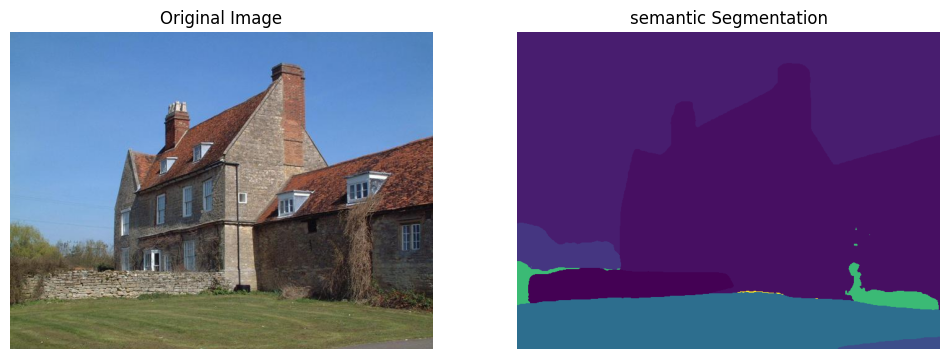

In [8]:
from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt


def run_segmentation(image, task_type):
    """Performs image segmentation based on the given task type.

    Args:
        image (PIL.Image): The input image.
        task_type (str): The type of segmentation to perform ('semantic', 'instance', or 'panoptic').

    Returns:
        PIL.Image: The segmented image.

    Raises:
        ValueError: If the task type is invalid.
    """

    processor = OneFormerProcessor.from_pretrained(
        "shi-labs/oneformer_ade20k_dinat_large"
    )  # Load once here
    model = OneFormerForUniversalSegmentation.from_pretrained(
       "shi-labs/oneformer_ade20k_swin_large"


    )

    if task_type == "semantic":
        inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_semantic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]

    elif task_type == "instance":
        inputs = processor(images=image, task_inputs=["instance"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_instance_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    elif task_type == "panoptic":
        inputs = processor(images=image, task_inputs=["panoptic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_panoptic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    else:
        raise ValueError(
            "Invalid task type. Choose from 'semantic', 'instance', or 'panoptic'"
        )

    return predicted_map


def show_image_comparison(image, predicted_map, segmentation_title):
    """Displays the original image and the segmented image side-by-side.

    Args:
        image (PIL.Image): The original image.
        predicted_map (PIL.Image): The segmented image.
        segmentation_title (str): The title for the segmented image.
    """

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(predicted_map)
    plt.title(segmentation_title + " Segmentation")
    plt.axis("off")
    plt.show()


url = "https://huggingface.co/datasets/shi-labs/oneformer_demo/resolve/main/ade20k.jpeg"
response = requests.get(url, stream=True)
response.raise_for_status()  # Check for HTTP errors
image = Image.open(response.raw)

task_to_run = "semantic"
predicted_map = run_segmentation(image, task_to_run)
show_image_comparison(image, predicted_map, task_to_run)

Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consid

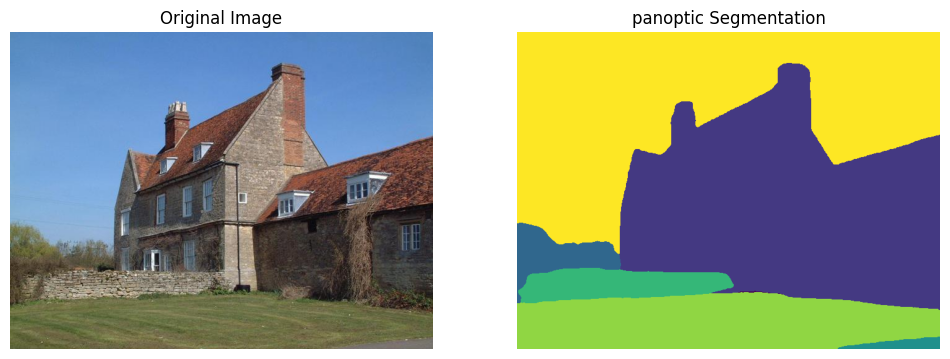

In [9]:
task_to_run ="panoptic"
predicted_map = run_segmentation(image, task_to_run)
show_image_comparison(image, predicted_map, task_to_run)

Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consid

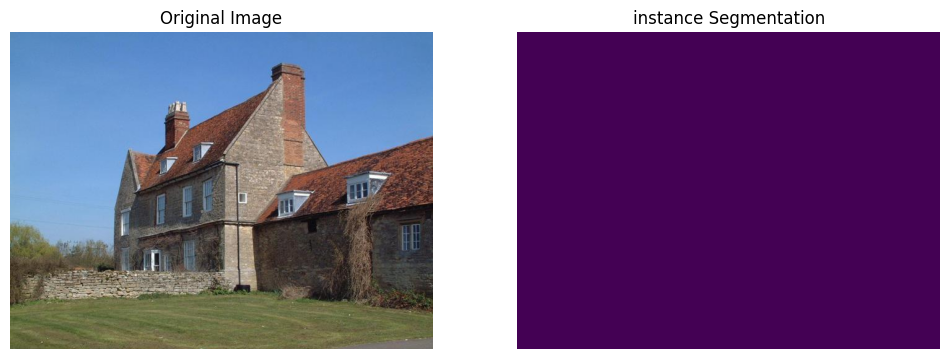

In [10]:
task_to_run = "instance"
predicted_map = run_segmentation(image, task_to_run)
show_image_comparison(image, predicted_map, task_to_run)